
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Felicidades Andrea! Tu trabajo es excelente. 

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Te recomiendo usar celdas de tipo **Markdown** para organizar mejor tu trabajo. Puedes agregar **títulos**, separar secciones y explicar tu código de manera clara. Esto no solo mejora la legibilidad, sino que también te ayuda a entender y explicar mejor tu proceso. 📚✍️

</div>

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

Proyecto: Análisis de los servicios de taxi en Chicago 

Recuperar los datos de condiciones meteorológicas de Chicago en noviembre de 2017.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Es una buena práctica separar la importación de bibliotecas de la carga de los datasets para que el código sea más legible y organizado. Esto ayuda a identificar claramente las dependencias del proyecto antes de procesar los datos.

</div>

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# 1. Obtención de datos meteorológicos
url = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'lxml')

# Localizar la tabla por ID
table = soup.find('table', attrs={"id": "weather_records"})

# Extraer encabezados y contenido
heading_table = [th.text for th in table.find_all('th')]
content = []
for tr in table.find_all('tr'):
    if not tr.find_all('th'):
        content.append([td.text for td in tr.find_all('td')])

weather_records = pd.DataFrame(content, columns=heading_table)
print("Registros climáticos recuperados:")
display(weather_records.head())

Registros climáticos recuperados:


,Date and time,Temperature,Description
0,2017-11-01 00:00:00,276.150,broken clouds
1,2017-11-01 01:00:00,275.700,scattered clouds
2,2017-11-01 02:00:00,275.610,overcast clouds
3,2017-11-01 03:00:00,275.350,broken clouds
4,2017-11-01 04:00:00,275.240,broken clouds


 Análisis Exploratorio con SQL 

Estos datos los tomé de la base de datos proporcionada y luego mediante las consultas SQL realizadas en esta base de datos

Primero hallé project_sql_result_01.csv para encontrar el número de viajes para cada empresa de taxis los días 15 y 16 de noviembre de 2017 para posteriormente unir las tablas cabs y trips y Filtrar por las fechas exactas y agrupar por el nombre de la empresa para contar los registros.


Análisis Exploratorio de Datos (Python)

#Importación y verificación de datos

Se realiza la carga de los resultados de consultas SQL y se verifica que los tipos de datos sean correctos.


In [11]:
# Cargar los datasets de los archivos CSV
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

# Verificar tipos de datos
print("Información de Empresas:")
print(df_companies.info())
print("\nInformación de Barrios (Finalizaciones):")
print(df_neighborhoods.info())

# Identificar los 10 barrios principales
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)
print("\nTop 10 barrios con más finalizaciones:")
display(top_10_neighborhoods)

Información de Empresas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

Información de Barrios (Finalizaciones):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None

Top 10 barrios con más finalizaciones:


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo estudiando los datasets! Esto es fundamental para entender los datos y planificar el análisis.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda dejar comentarios sobre tus análisis de los mismos. 

</div>

</div>

Visualización de datos

Gráfico 1: Empresas de taxis y número de viajes

10 empresas con mayor volumen de viajes para entender la competencia.

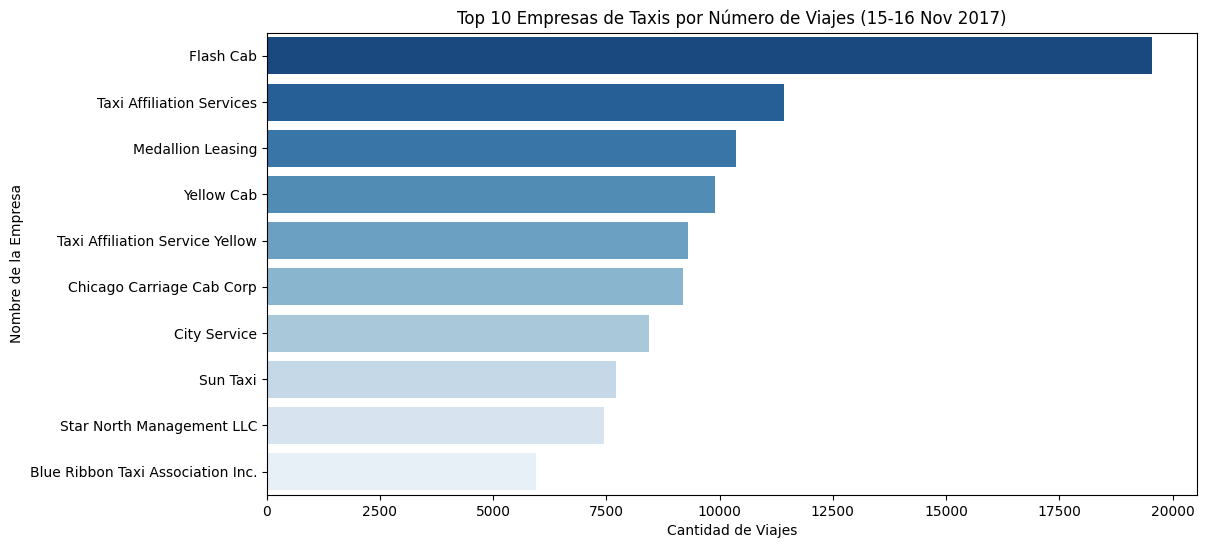

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_companies.sort_values(by='trips_amount', ascending=False).head(10), 
            x='trips_amount', y='company_name', palette='Blues_r')
plt.title('Top 10 Empresas de Taxis por Número de Viajes (15-16 Nov 2017)')
plt.xlabel('Cantidad de Viajes')
plt.ylabel('Nombre de la Empresa')
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Correcto! El gráfico es correcto y refleja adecuadamente el resultado esperado.

</div>

Conclusiones: 
Se observa una dominancia clara de Flash Cab, seguida de Taxi Affiliation Services. 
Estas empresas poseen la mayor cuota de mercado en los días analizados.

Gráfico 2: Top 10 barrios por finalizaciones
Destinos más populares en Chicago durante noviembre.

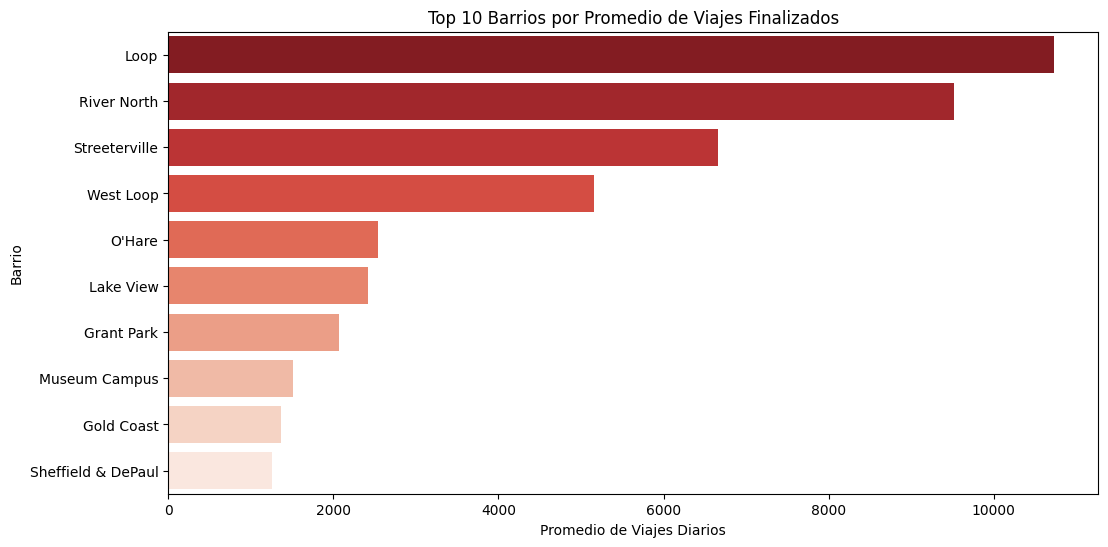

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_neighborhoods, x='average_trips', y='dropoff_location_name', palette='Reds_r')
plt.title('Top 10 Barrios por Promedio de Viajes Finalizados')
plt.xlabel('Promedio de Viajes Diarios')
plt.ylabel('Barrio')
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El gráfico de barras con el top 10 por barrios es excelente y los resultados son los esperados. 

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Nota que podrías encapsular parte de la lógica para reutilizar el código, ya que es muy similar al gráfico anterior. 

</div>

</div>

Conclusión: El barrio Loop es el destino principal con una diferencia considerable, seguido por River North. Esto indica que la actividad se concentra en el distrito financiero y áreas turísticas.

Prueba de Hipótesis
Hipótesis: "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

H0 (Hipótesis Nula): La duración promedio de los viajes el Loop al O'Hare es igual en sábados lluviosos y no lluviosos.

H1 (Hipótesis Alternativa): La duración promedio de los viajes es diferente entre sábados lluviosos y despejados.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo formulando la hipótesis! Es fundamental que sea claro lo que se busca analizar.

</div>

In [15]:
# Cargar datos para la prueba
df_hyp = pd.read_csv('/datasets/project_sql_result_07.csv')

# Separar las muestras por condición climática
good_weather_duration = df_hyp[df_hyp['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_duration = df_hyp[df_hyp['weather_conditions'] == 'Bad']['duration_seconds']

# Nivel de significancia
alpha = 0.05

# Realizar prueba t de Student para dos muestras independientes
results = st.ttest_ind(good_weather_duration, bad_weather_duration, equal_var=False)

print(f'Valor p: {results.pvalue}')

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración de los viajes.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia de una diferencia significativa.")

Valor p: 6.738994326108734e-12
Rechazamos la hipótesis nula: Hay una diferencia significativa en la duración de los viajes.


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al realizar una prueba de hipótesis, es muy importante verificar los supuestos. El t-test que usaste funciona bien cuando se cumplen ciertos supuestos, como que las varianzas de ambos grupos (sábados lluviosos y no lluviosos) sean similares. Puedes realizar la prueba de levene para comprobar que los dos grupos tienen la misma varianza y, de esta forma, podrás saber el valor del parámetro equal_var que se debe utilizar en la función stats.ttest_ind.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Interpretaste correctamente el valor p y sacaste conclusiones estadísticas válidas. Debemos rechazar efectivamente la hipótesis nula. 

</div>
    
</div>

Análisis de resultados

Utilicé Prueba t de Student porque necesitaba comparar las medias de dos poblaciones independientes (viajes en clima bueno vs clima malo). 
Usé equal_var=False ya que no podemos asumir que las varianzas de ambos grupos son iguales (Prueba de Welch).

Entonces se puede concluir que si el valor p es menor a 0.05, se puede afirmar que factores externos como la lluvia impactan directamente en el tiempo de traslado hacia el aeropuerto, lo cual es una información vital para que Zuber optimice sus promesas de tiempo de llegada a los usuarios.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Dejas durante todo el proyecto comentarios correctos y conclusiones super claras.

</div>